In [2]:
# this project uses data collected about Hard Disks using S.M.A.R.T (Self-Monitoring, Analysis, and Reporting Technology) sensor logs. It is a very big set of data,
# it does sutisfy the orders for the project regarding the size of features and overall data and it even dramatically exceeds it, so we started by wrangling data:

In [3]:
# ==============================================================================
# 1. WRANGLING OPERATION (By Bevnoty Mamdouh)
# ==============================================================================
import pandas as pd 
import glob 
import os 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, classification_report

folder_path = './data_Q4_2025/data_Q4_2025'
all_files = glob.glob(os.path.join(folder_path, "*.csv"))

if len(all_files) == 0: 
    raise FileNotFoundError(f"No CSV files found in: {folder_path}.")

print(f"Found {len(all_files)} files. processing... ")

sampled_chunks = []

for file in all_files:
    chunk_container = pd.read_csv(file, chunksize=50000) 
    
    for chunk in chunk_container: 
        failures = chunk[chunk['failure'] == 1] 
        healthy = chunk[chunk['failure'] == 0].sample(frac=0.005, random_state=42)
        
        sampled_chunks.append(failures)
        sampled_chunks.append(healthy)

final_df = pd.concat(sampled_chunks, ignore_index=True)

metadata_cols = ['date', 'serial_number', 'model', 'capacity_bytes']
final_df = final_df.drop(columns=[col for col in metadata_cols if col in final_df.columns]) 

threshold = len(final_df) * 0.50
final_df = final_df.dropna(thresh=threshold, axis=1)
final_df = final_df.fillna(final_df.median(numeric_only=True)) 

print(f"--- WRANGLING COMPLETE ---")
print(f"final dataset has {final_df.shape[0]} rows and {final_df.shape[1]} columns.")

Found 92 files. processing... 
--- WRANGLING COMPLETE ---
final dataset has 155655 rows and 43 columns.


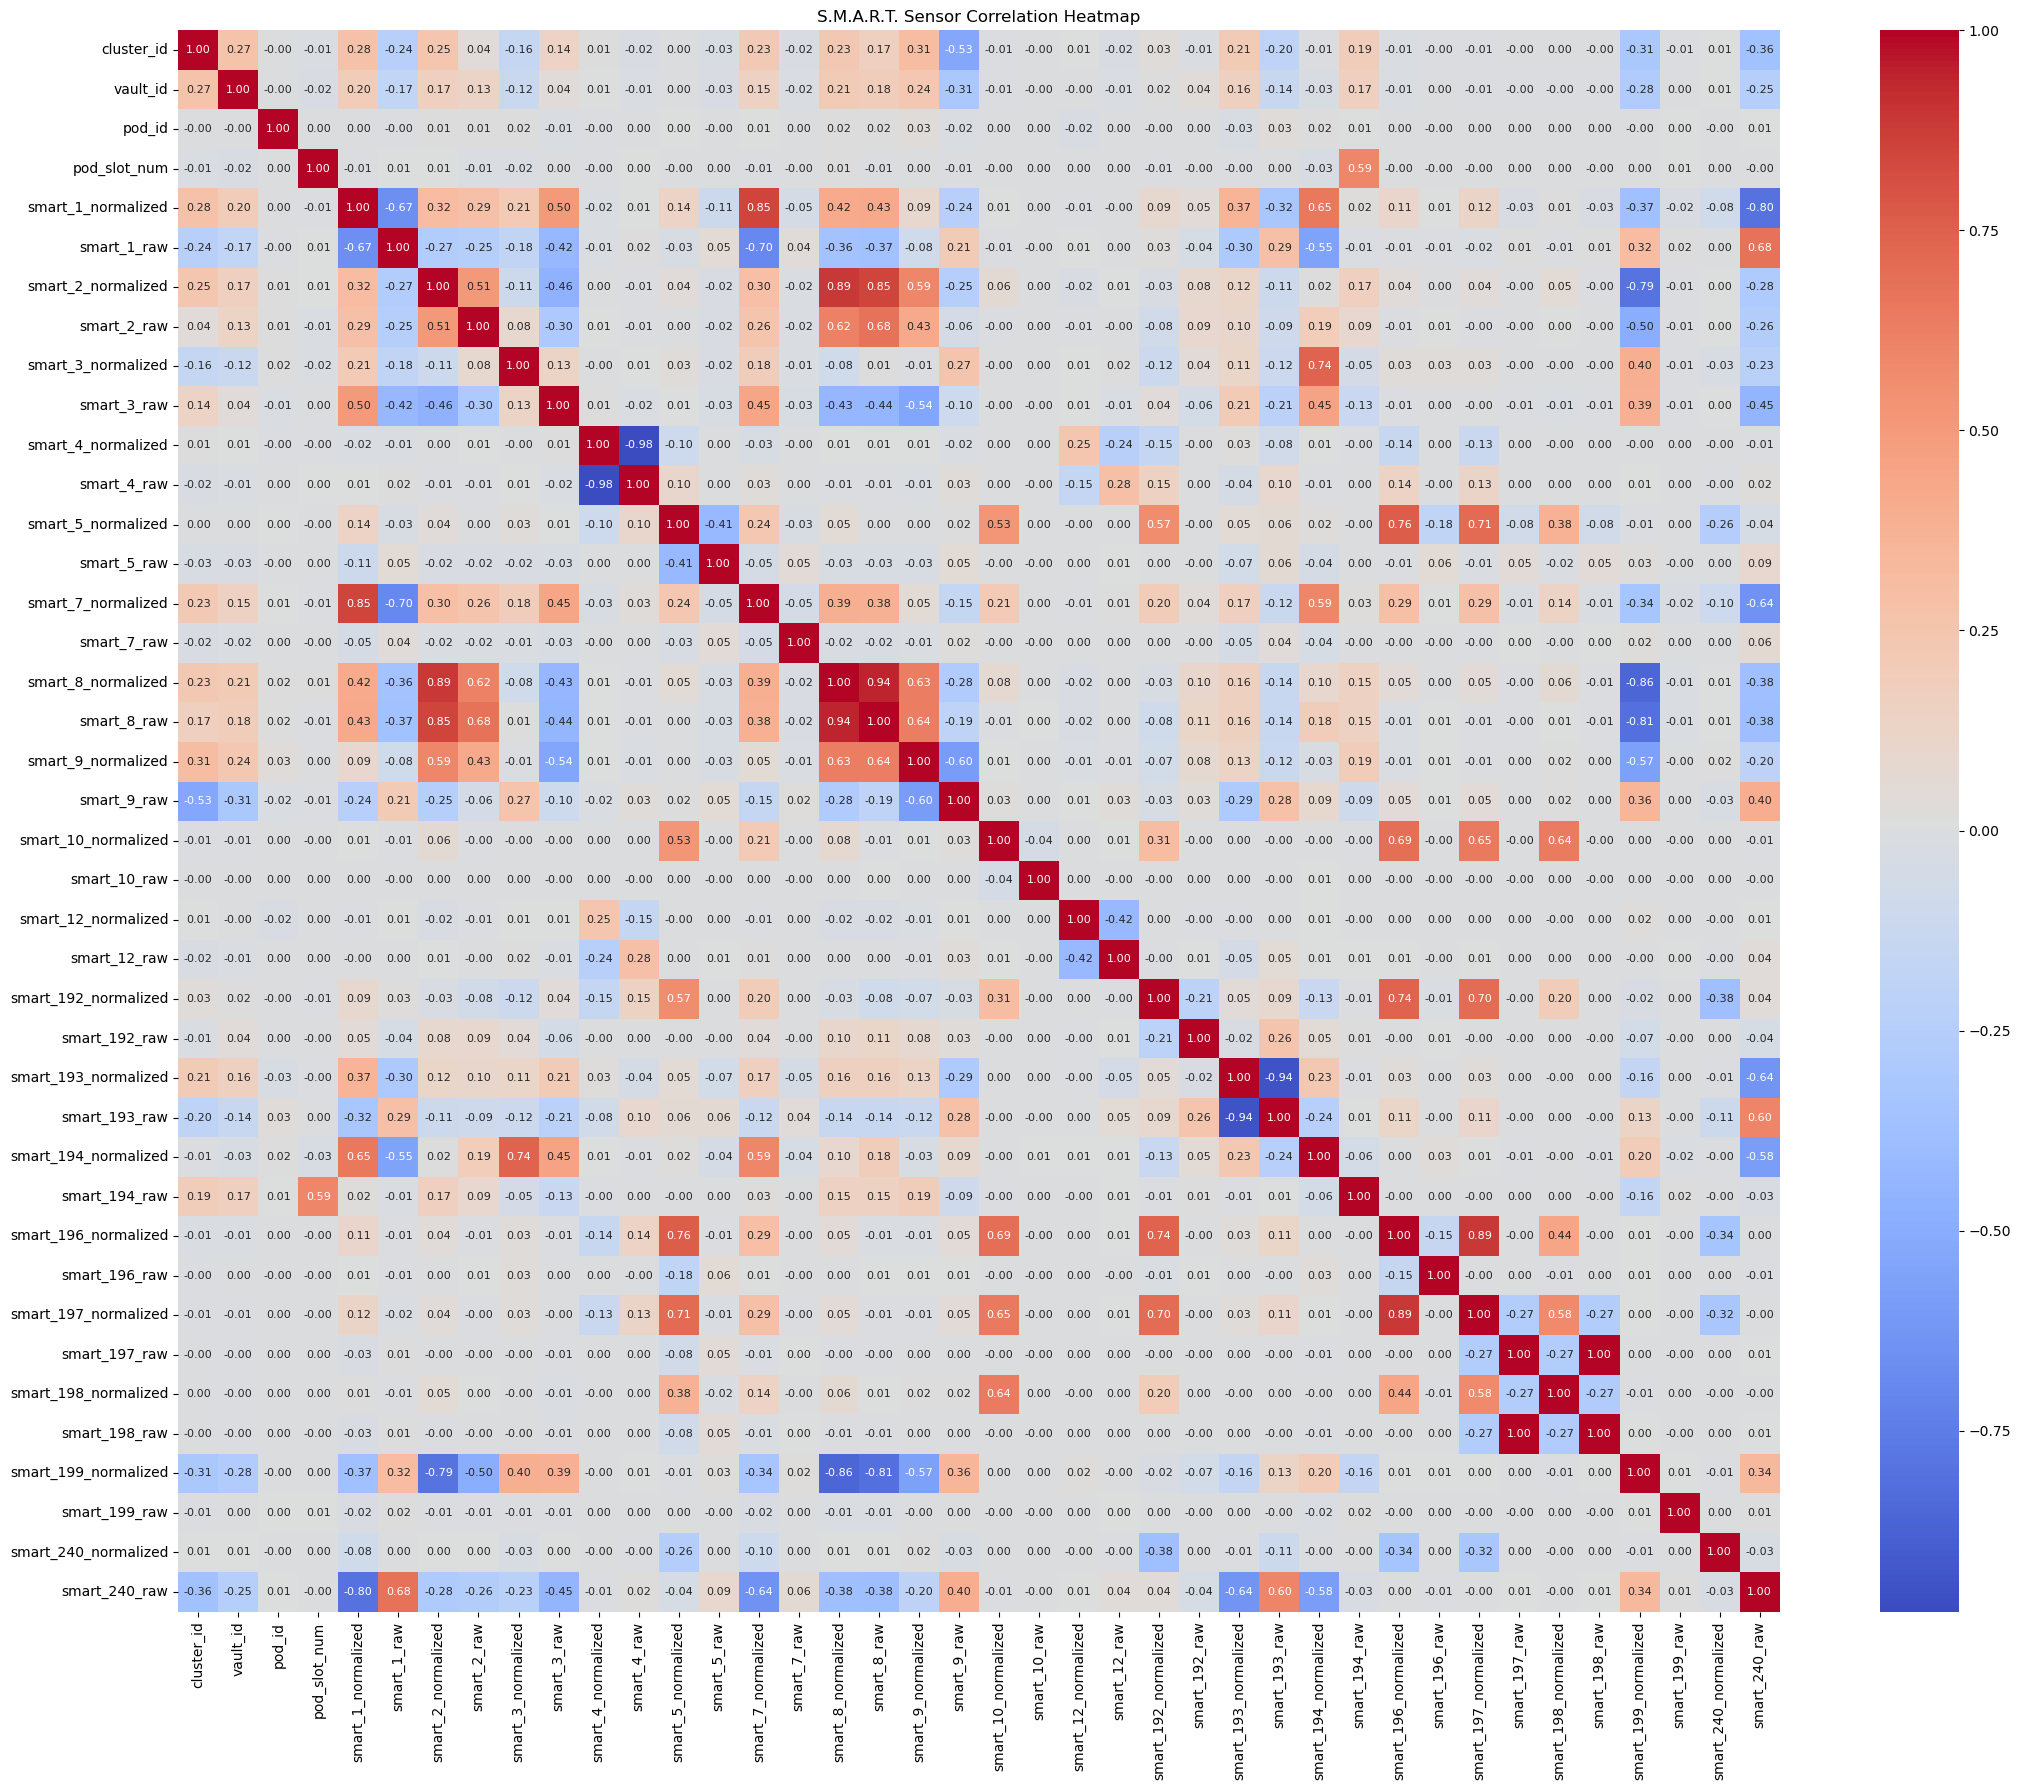


--- Applying PCA (Dimension Reduction) ---


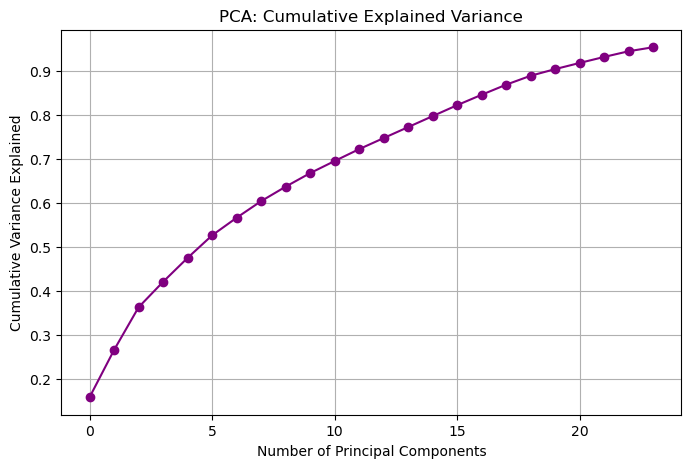


--- Running Feature Selection ---
Feature Selection kept the top 10 physical sensors:
 - smart_1_normalized
 - smart_3_normalized
 - smart_5_normalized
 - smart_5_raw
 - smart_7_raw
 - smart_196_raw
 - smart_197_normalized
 - smart_197_raw
 - smart_198_normalized
 - smart_198_raw


In [4]:
# ==============================================================================
# 2. EDA & DIMENSIONALITY REDUCTION (By Andrew Ashraf)
# ==============================================================================
X = final_df.drop(columns=['failure'])
y = final_df['failure']
X = X.select_dtypes(include=[np.number])

# Correlation Heatmap
plt.figure(figsize=(22, 18))
corr_matrix = X.corr()
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt=".2f", annot_kws={"size": 8})
plt.title("S.M.A.R.T. Sensor Correlation Heatmap")
plt.tight_layout()
plt.show()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# PCA
print("\n--- Applying PCA (Dimension Reduction) ---")
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='-', color='purple')
plt.title('PCA: Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Variance Explained')
plt.grid(True)
plt.show()

# SelectKBest (Final Choice)
print("\n--- Running Feature Selection ---")
selector = SelectKBest(score_func=f_classif, k=10)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

winning_columns = X.columns[selector.get_support()]
print(f"Feature Selection kept the top 10 physical sensors:")
for col in winning_columns:
    print(f" - {col}")


--- Generating Hyperparameter Diagram ---


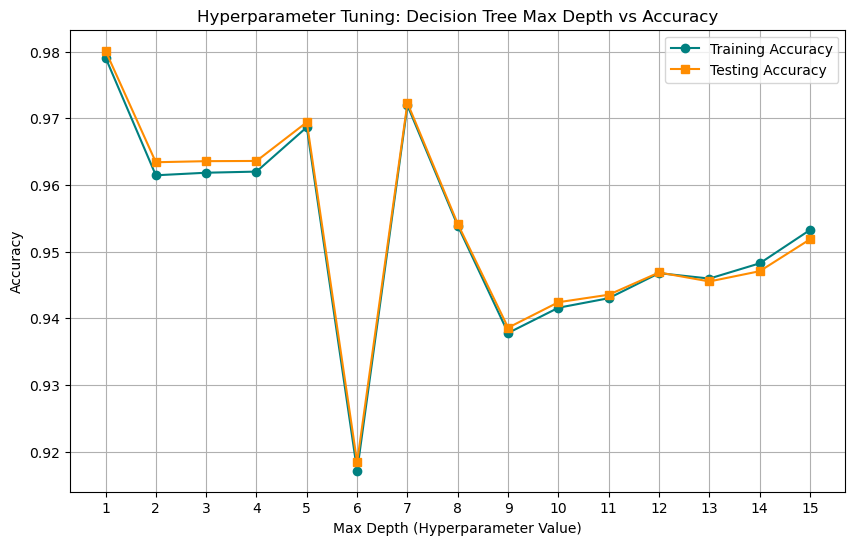

In [5]:
# ==============================================================================
# 3. HYPERPARAMETER TUNING
# ==============================================================================
print("\n--- Generating Hyperparameter Diagram ---")
depths = range(1, 16)
train_accuracies = []
test_accuracies = []

for depth in depths:
    temp_tree = DecisionTreeClassifier(max_depth=depth, class_weight='balanced', random_state=42)
    temp_tree.fit(X_train_selected, y_train) 
    train_accuracies.append(accuracy_score(y_train, temp_tree.predict(X_train_selected)))
    test_accuracies.append(accuracy_score(y_test, temp_tree.predict(X_test_selected)))

plt.figure(figsize=(10, 6))
plt.plot(depths, train_accuracies, label='Training Accuracy', marker='o', color='teal')
plt.plot(depths, test_accuracies, label='Testing Accuracy', marker='s', color='darkorange')
plt.title('Hyperparameter Tuning: Decision Tree Max Depth vs Accuracy')
plt.xlabel('Max Depth (Hyperparameter Value)')
plt.ylabel('Accuracy')
plt.xticks(depths) 
plt.legend()
plt.grid(True)
plt.show()

Training Baseline Models...


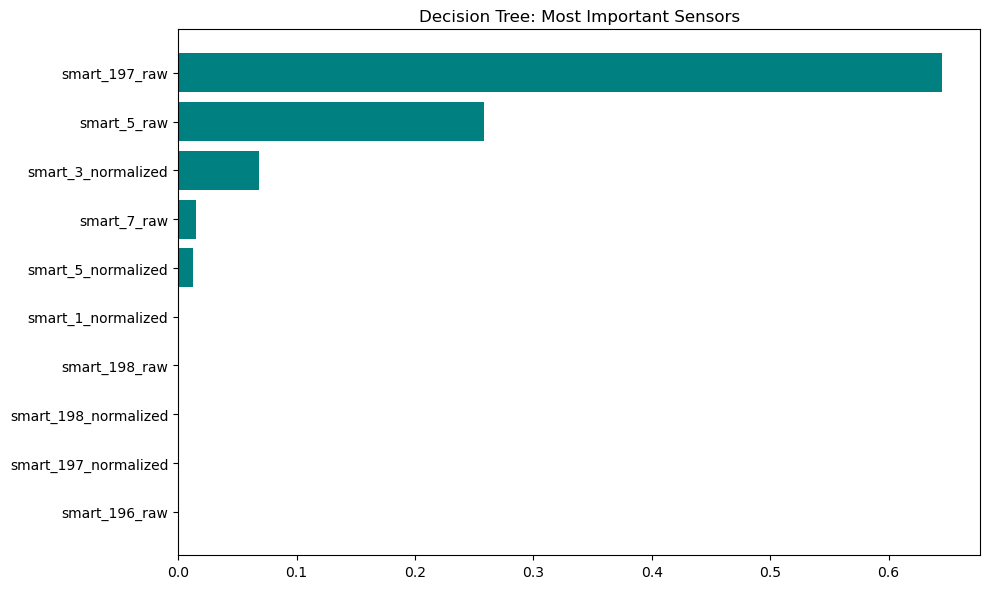

Training Random Forest Model...


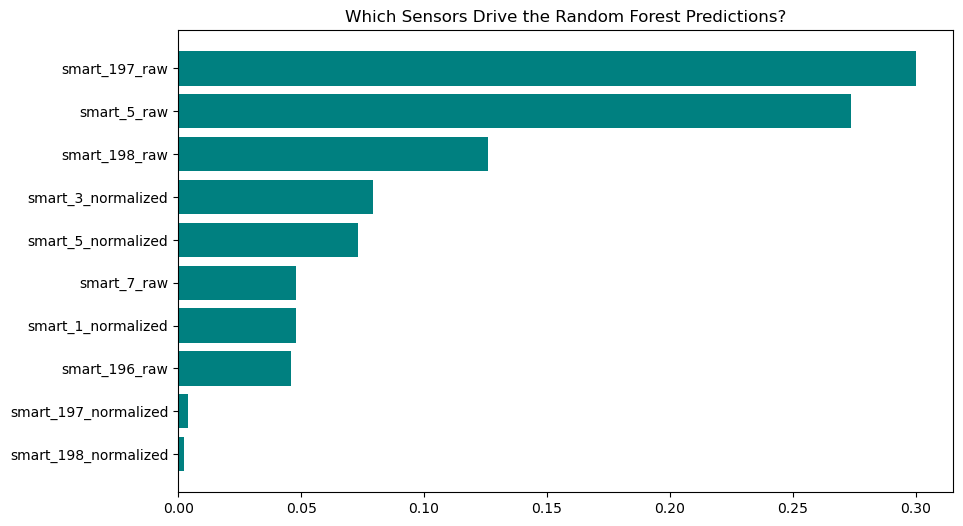

In [6]:
# ==============================================================================
# 4. BASELINE & ADVANCED MODELS
# ==============================================================================
print("Training Baseline Models...")
log_model = LogisticRegression(class_weight='balanced', max_iter=1000)
log_model.fit(X_train_selected, y_train)
log_pred = log_model.predict(X_test_selected)

tree_model = DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)
tree_model.fit(X_train_selected, y_train)
tree_pred = tree_model.predict(X_test_selected)

tree_df = pd.DataFrame({'Sensor': winning_columns, 'Importance Score': tree_model.feature_importances_}).sort_values(by='Importance Score', ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(tree_df['Sensor'], tree_df['Importance Score'], color='teal')
plt.title("Decision Tree: Most Important Sensors")
plt.tight_layout()
plt.show()

print("Training Random Forest Model...")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train_selected, y_train)
rf_pred = rf_model.predict(X_test_selected)

importance_df = pd.DataFrame({'Sensor': winning_columns, 'Importance': rf_model.feature_importances_}).sort_values(by='Importance', ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Sensor'], importance_df['Importance'], color='teal')
plt.title("Which Sensors Drive the Random Forest Predictions?")
plt.show()

Training models on FULL dataset (Before Reduction) for comparison...


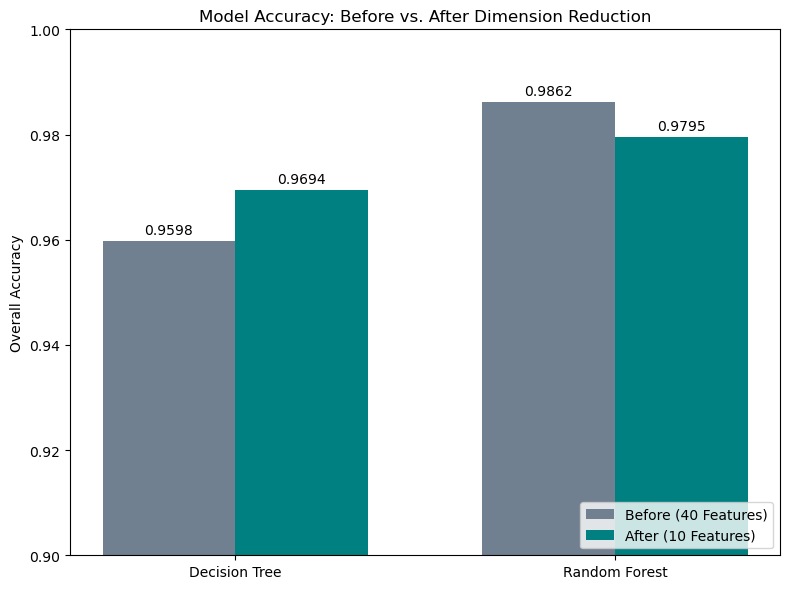


Conclusion: Dimension reduction maintained roughly the same accuracy while dropping 75% of the data columns, making the model faster, lighter, and highly explainable.


In [7]:
# --- BEFORE VS AFTER DIMENSION REDUCTION ---
import matplotlib.pyplot as plt
import numpy as np

print("Training models on FULL dataset (Before Reduction) for comparison...")

# Train models on ALL features (X_train_scaled)
tree_before = DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)
tree_before.fit(X_train_scaled, y_train)

rf_before = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
rf_before.fit(X_train_scaled, y_train)

# Calculate Accuracies
# 1. Before Reduction (40 Features)
dt_acc_before = tree_before.score(X_test_scaled, y_test)
rf_acc_before = rf_before.score(X_test_scaled, y_test)

# 2. After Reduction (10 Features - Using the models we already trained)
dt_acc_after = tree_model.score(X_test_selected, y_test)
rf_acc_after = rf_model.score(X_test_selected, y_test)

# --- PLOTTING THE DIFFERENCE ---
labels = ['Decision Tree', 'Random Forest']
before_scores = [dt_acc_before, rf_acc_before]
after_scores = [dt_acc_after, rf_acc_after]

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(8, 6))
rects1 = ax.bar(x - width/2, before_scores, width, label='Before (40 Features)', color='slategray')
rects2 = ax.bar(x + width/2, after_scores, width, label='After (10 Features)', color='teal')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Overall Accuracy')
ax.set_title('Model Accuracy: Before vs. After Dimension Reduction')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0.9, 1.0) # Zoom in to see the differences clearly
ax.legend(loc='lower right')

# Attach a text label above each bar, displaying its height.
ax.bar_label(rects1, padding=3, fmt='%.4f')
ax.bar_label(rects2, padding=3, fmt='%.4f')

fig.tight_layout()
plt.show()

print("\nConclusion: Dimension reduction maintained roughly the same accuracy while dropping 75% of the data columns, making the model faster, lighter, and highly explainable.")


===== Logistic Regression Results =====


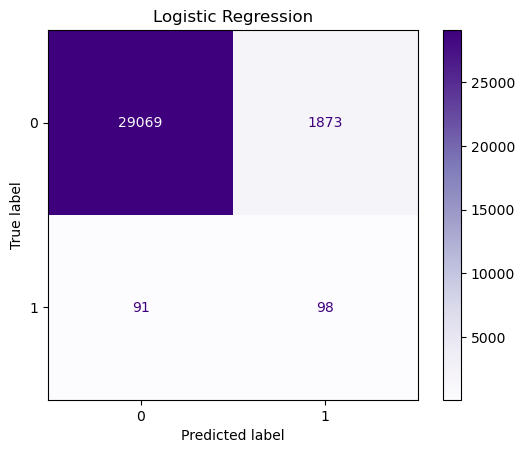

              precision    recall  f1-score   support

           0       1.00      0.94      0.97     30942
           1       0.05      0.52      0.09       189

    accuracy                           0.94     31131
   macro avg       0.52      0.73      0.53     31131
weighted avg       0.99      0.94      0.96     31131


===== Decision Tree Results =====


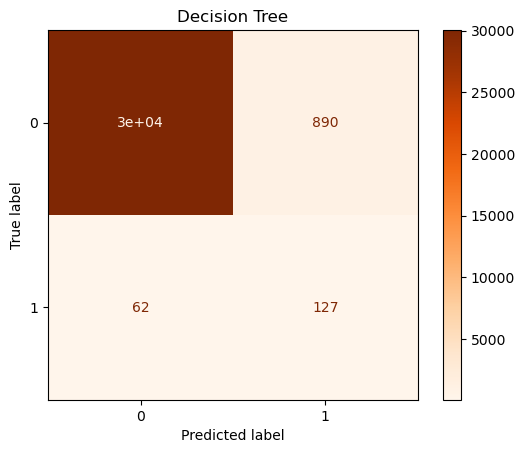

              precision    recall  f1-score   support

           0       1.00      0.97      0.98     30942
           1       0.12      0.67      0.21       189

    accuracy                           0.97     31131
   macro avg       0.56      0.82      0.60     31131
weighted avg       0.99      0.97      0.98     31131


===== Random Forest Results =====


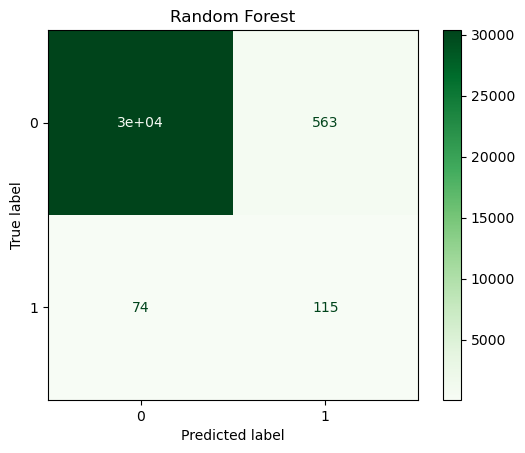

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     30942
           1       0.17      0.61      0.27       189

    accuracy                           0.98     31131
   macro avg       0.58      0.80      0.63     31131
weighted avg       0.99      0.98      0.99     31131



In [8]:
# ==============================================================================
# 5. MODEL EVALUATION
# ==============================================================================
print("\n===== Logistic Regression Results =====")
ConfusionMatrixDisplay.from_predictions(y_test, log_pred, cmap='Purples')
plt.title("Logistic Regression")
plt.show()
print(classification_report(y_test, log_pred))

print("\n===== Decision Tree Results =====")
ConfusionMatrixDisplay.from_predictions(y_test, tree_pred, cmap='Oranges')
plt.title("Decision Tree")
plt.show()
print(classification_report(y_test, tree_pred))

print("\n===== Random Forest Results =====")
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, cmap='Greens')
plt.title("Random Forest")
plt.show()
print(classification_report(y_test, rf_pred))

In [9]:
# If Backblaze wants maximum data safety and doesn't mind paying engineers to check a lot of false alarms, The Decision Tree model is the best because it catches 67% of all crashes.
# If Backblaze wants the most balanced system that catches 61% of crashes but saves money by minimizing false alarms, The Random Forest model is our top recommendation.